In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet('/content/drive/MyDrive/Dissertation/Data/phase2_features.parquet')
feature_cols = joblib.load('/content/drive/MyDrive/Dissertation/Data/feature_names.pkl')

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Features for modelling: {len(feature_cols)}")

Mounted at /content/drive
Rows: 363,250
Columns: 62
Features for modelling: 19


In [2]:
epc_map = {1:'G', 2:'F', 3:'E', 4:'D', 5:'C', 6:'B', 7:'A'}

epc_stats = df.groupby('epc_numeric')['price_per_sqm'].agg(['median', 'mean', 'count'])
epc_stats.index = epc_stats.index.map(epc_map)
epc_stats = epc_stats.reindex(['G','F','E','D','C','B','A'])

print(epc_stats)

                  median         mean   count
epc_numeric                                  
G            1912.672476  2259.491709    1646
F            2152.475845  2428.427115    5854
E            2229.729730  2470.452065   37821
D            2355.371901  2548.746538  148609
C            2413.793103  2634.964605  117738
B            2928.571429  3186.334920   50766
A            3142.674890  3004.416459     816


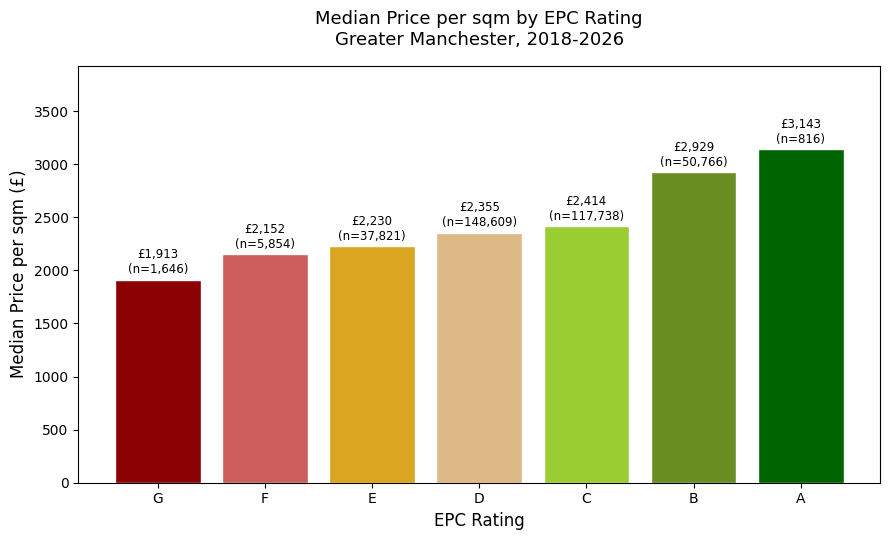

Chart 1 saved.


In [3]:
fig, ax = plt.subplots(figsize=(9, 5.5))

order = ['G','F','E','D','C','B','A']
colors = ['#8B0000','#CD5C5C','#DAA520','#DEB887','#9ACD32','#6B8E23','#006400']

bars = ax.bar(epc_stats.loc[order].index, epc_stats.loc[order]['median'],
              color=colors, edgecolor='white', linewidth=1)

for bar, val, n in zip(bars, epc_stats.loc[order]['median'], epc_stats.loc[order]['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'£{val:,.0f}\n(n={n:,})', ha='center', va='bottom', fontsize=8.5)

ax.set_xlabel('EPC Rating', fontsize=12)
ax.set_ylabel('Median Price per sqm (£)', fontsize=12)
ax.set_title('Median Price per sqm by EPC Rating\nGreater Manchester, 2018-2026',
             fontsize=13, pad=15)
ax.set_ylim(0, max(epc_stats['median']) * 1.25)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Dissertation/Charts/chart1_epc_price_premium.png',
            dpi=200, bbox_inches='tight')
plt.show()

print("Chart 1 saved.")

In [4]:
df['sale_date'] = pd.to_datetime(dict(year=df['sale_year'], month=df['sale_month'], day=1))
df['sale_quarter_period'] = df['sale_date'].dt.to_period('Q')

quarterly = df.groupby('sale_quarter_period')['price'].median().reset_index()
quarterly['sale_quarter_period'] = quarterly['sale_quarter_period'].dt.to_timestamp()

print(quarterly.head(10))
print(f"\nTotal quarters: {len(quarterly)}")

  sale_quarter_period     price
0          2018-01-01  155000.0
1          2018-04-01  159000.0
2          2018-07-01  162500.0
3          2018-10-01  160000.0
4          2019-01-01  155000.0
5          2019-04-01  164950.0
6          2019-07-01  167000.0
7          2019-10-01  168000.0
8          2020-01-01  170000.0
9          2020-04-01  167995.0

Total quarters: 33


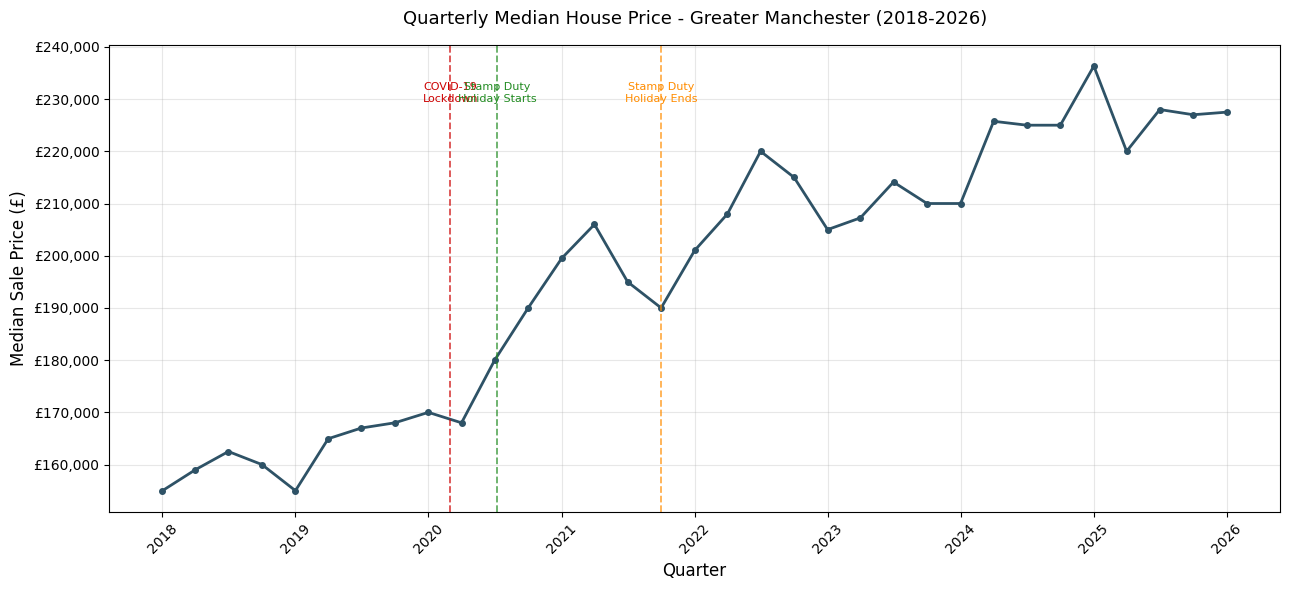

Chart 2 saved.


In [5]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(quarterly['sale_quarter_period'], quarterly['price'],
        marker='o', linewidth=2, color='#2E5266', markersize=4)

events = [
    ('2020-03-01', 'COVID-19\nLockdown', '#CC0000'),
    ('2020-07-08', 'Stamp Duty\nHoliday Starts', '#228B22'),
    ('2021-09-30', 'Stamp Duty\nHoliday Ends', '#FF8C00'),
]

for date, label, color in events:
    ax.axvline(pd.to_datetime(date), color=color, linestyle='--', alpha=0.7, linewidth=1.3)
    ax.text(pd.to_datetime(date), ax.get_ylim()[1]*0.97 if ax.get_ylim()[1] else max(quarterly['price'])*1.02,
            label, rotation=0, fontsize=8, color=color, ha='center', va='top')

ax.set_xlabel('Quarter', fontsize=12)
ax.set_ylabel('Median Sale Price (£)', fontsize=12)
ax.set_title('Quarterly Median House Price - Greater Manchester (2018-2026)', fontsize=13, pad=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'£{x:,.0f}'))
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Dissertation/Charts/chart2_quarterly_timeseries.png',
            dpi=200, bbox_inches='tight')
plt.show()

print("Chart 2 saved.")

In [6]:
import folium
from folium.plugins import HeatMap

print("Folium version:", folium.__version__)

# Aggregate real data by postcode district for mapping
district_prices = df.groupby('postcode_district').agg(
    median_price=('price', 'median'),
    avg_lat=('latitude', 'mean'),
    avg_lon=('longitude', 'mean'),
    count=('price', 'count')
).reset_index()

district_prices = district_prices[district_prices['count'] >= 30]  # drop tiny/unreliable districts

print(f"Districts with sufficient data: {len(district_prices)}")
print(district_prices.sort_values('median_price', ascending=False).head(10))

Folium version: 0.20.0
Districts with sufficient data: 89
   postcode_district  median_price    avg_lat   avg_lon  count
81              WA13      645000.0  53.400034 -2.435458     46
68              SK12      600000.0  53.361778 -2.062025     43
83              WA15      440000.0  53.387626 -2.327345   5485
78               SK7      360000.0  53.367613 -2.142828   6691
82              WA14      355000.0  53.391321 -2.356120   5100
22               M21      340100.0  53.438683 -2.274305   3345
20                M2      340000.0  53.480993 -2.244754     56
35               M33      325000.0  53.420811 -2.324911   8041
79               SK8      320000.0  53.379314 -2.208637   8492
75               SK4      300000.0  53.420102 -2.183492   4946


In [7]:
m = folium.Map(location=[53.4808, -2.2426], zoom_start=10, tiles='cartodbpositron')

import branca.colormap as cm
colormap = cm.LinearColormap(
    colors=['#2c7bb6', '#abd9e9', '#ffffbf', '#fdae61', '#d7191c'],
    vmin=district_prices['median_price'].min(),
    vmax=district_prices['median_price'].max(),
    caption='Median Sale Price (£)'
)

for _, row in district_prices.iterrows():
    folium.CircleMarker(
        location=[row['avg_lat'], row['avg_lon']],
        radius=6,
        popup=f"{row['postcode_district']}: £{row['median_price']:,.0f} (n={row['count']})",
        color=colormap(row['median_price']),
        fill=True,
        fill_color=colormap(row['median_price']),
        fill_opacity=0.8,
        weight=1
    ).add_to(m)

colormap.add_to(m)
m.save('/content/drive/MyDrive/Dissertation/Charts/chart3_price_map.html')
print("Chart 3 saved as HTML.")
m

Chart 3 saved as HTML.


In [8]:
prop_type_map = {
    'D': 'Detached',
    'S': 'Semi-detached',
    'T': 'Terraced',
    'F': 'Flat',
    'O': 'Other'
}

df['property_type_label_clean'] = df['property_type_ppd'].map(prop_type_map)

print(df['property_type_label_clean'].value_counts())

property_type_label_clean
Terraced         122239
Semi-detached    117640
Flat              62140
Detached          49425
Other             11806
Name: count, dtype: int64


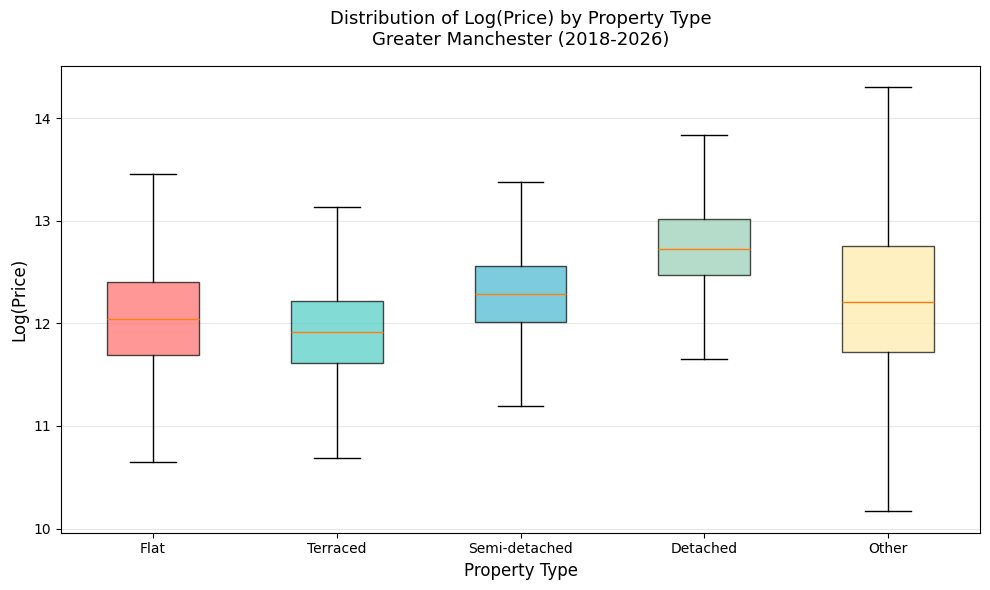

Chart 4 saved.


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

order = ['Flat', 'Terraced', 'Semi-detached', 'Detached', 'Other']
plot_data = [df[df['property_type_label_clean'] == pt]['log_price'].dropna() for pt in order]

bp = ax.boxplot(plot_data, labels=order, patch_artist=True, showfliers=False)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xlabel('Property Type', fontsize=12)
ax.set_ylabel('Log(Price)', fontsize=12)
ax.set_title('Distribution of Log(Price) by Property Type\nGreater Manchester (2018-2026)', fontsize=13, pad=15)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Dissertation/Charts/chart4_boxplot_proptype.png',
            dpi=200, bbox_inches='tight')
plt.show()

print("Chart 4 saved.")

In [10]:
!pip install -q libpysal esda
print("Libraries installed.")

Libraries installed.


In [11]:
from libpysal.weights import KNN
from esda.moran import Moran

np.random.seed(42)
sample = df.dropna(subset=['latitude','longitude','log_price']).sample(n=5000, random_state=42)

coords = sample[['longitude','latitude']].values
w = KNN.from_array(coords, k=8)
w.transform = 'r'

moran = Moran(sample['log_price'].values, w)

print(f"Sample size: {len(sample):,}")
print(f"Moran's I: {moran.I:.4f}")
print(f"Expected I (null): {moran.EI:.4f}")
print(f"p-value: {moran.p_sim:.4f}")
print(f"z-score: {moran.z_sim:.4f}")

Sample size: 5,000
Moran's I: 0.4226
Expected I (null): -0.0002
p-value: 0.0010
z-score: 64.2815


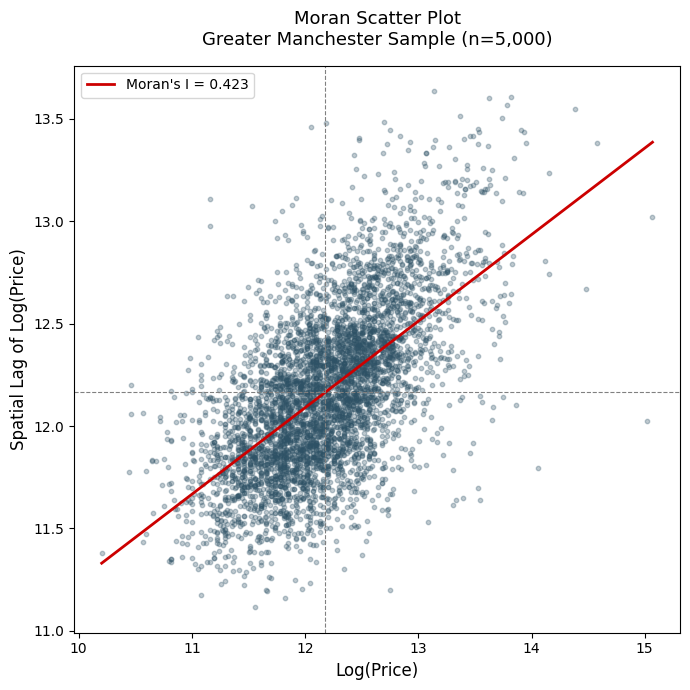

Chart 5 saved.

Moran's I: 0.4226, p-value: 0.0010, z-score: 64.2815


In [12]:
from esda.moran import Moran_Local
import matplotlib.pyplot as plt

lag = w.sparse.dot(sample['log_price'].values)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(sample['log_price'], lag, alpha=0.3, s=10, color='#2E5266')

z = sample['log_price'] - sample['log_price'].mean()
lag_z = lag - lag.mean()
b, a = np.polyfit(z, lag_z, 1)
xs = np.linspace(z.min(), z.max(), 100)
ax.plot(xs + sample['log_price'].mean(), b*xs + a + lag.mean(), color='#CC0000', linewidth=2,
        label=f"Moran's I = {moran.I:.3f}")

ax.axhline(lag.mean(), color='gray', linestyle='--', linewidth=0.8)
ax.axvline(sample['log_price'].mean(), color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Log(Price)', fontsize=12)
ax.set_ylabel('Spatial Lag of Log(Price)', fontsize=12)
ax.set_title(f"Moran Scatter Plot\nGreater Manchester Sample (n={len(sample):,})", fontsize=13, pad=15)
ax.legend()
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Dissertation/Charts/chart5_moran_scatter.png',
            dpi=200, bbox_inches='tight')
plt.show()

print("Chart 5 saved.")
print(f"\nMoran's I: {moran.I:.4f}, p-value: {moran.p_sim:.4f}, z-score: {moran.z_sim:.4f}")